### 1. Install & Setup

In [1]:
%pip install pyspark

Note: you may need to restart the kernel to use updated packages.


### 2. Import & Inisialisasi Spark

In [2]:
import os
os.environ['JAVA_TOOL_OPTIONS'] = '-Djava.security.manager=allow'

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("NYC Taxi Fare Prediction") \
    .config("spark.executor.memory", "4g") \
    .getOrCreate()

### 3. Load Data

In [3]:
import os

# Cari file train.csv dari beberapa kemungkinan lokasi
candidate_paths = ["train.csv", "../train.csv"]
train_path = next((p for p in candidate_paths if os.path.exists(p)), None)

if train_path is None:
    raise FileNotFoundError("train.csv tidak ditemukan di folder notebook maupun parent folder")

df = spark.read.csv(train_path, header=True, inferSchema=True)

print(f"Loaded from: {train_path}")
df.printSchema()
df.show(5)
print("Total rows:", df.count())

Loaded from: ../train.csv
root
 |-- key: timestamp (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- pickup_datetime: timestamp (nullable = true)
 |-- pickup_longitude: double (nullable = true)
 |-- pickup_latitude: double (nullable = true)
 |-- dropoff_longitude: double (nullable = true)
 |-- dropoff_latitude: double (nullable = true)
 |-- passenger_count: integer (nullable = true)

+-------------------+-----------+-------------------+----------------+---------------+-----------------+----------------+---------------+
|                key|fare_amount|    pickup_datetime|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|passenger_count|
+-------------------+-----------+-------------------+----------------+---------------+-----------------+----------------+---------------+
|2009-06-15 17:26:21|        4.5|2009-06-16 00:26:21|      -73.844311|      40.721319|        -73.84161|       40.712278|              1|
|2010-01-05 16:52:16|       16.9|2010-01-05 2

### 4. Statistik Deskriptif

In [4]:
df.describe(['fare_amount', 'passenger_count', 
             'pickup_longitude', 'pickup_latitude',
             'dropoff_longitude', 'dropoff_latitude']).show()

+-------+------------------+------------------+------------------+-----------------+------------------+------------------+
|summary|       fare_amount|   passenger_count|  pickup_longitude|  pickup_latitude| dropoff_longitude|  dropoff_latitude|
+-------+------------------+------------------+------------------+-----------------+------------------+------------------+
|  count|          55423856|          55423856|          55423856|         55423856|          55423480|          55423480|
|   mean|11.345045601663852|1.6853799201556816|-72.50968444358729| 39.9197917868882|-72.51120972971809|39.920681444828844|
| stddev|  20.7108321982325|1.3276643570959683| 12.84888338140265|9.642353041994934|12.782196517830771| 9.633345796415124|
|    min|            -300.0|                 0|      -3442.059565|     -3492.263768|      -3442.024565|      -3547.886698|
|    max|          93963.36|               208|       3457.625683|      3408.789565|        3457.62235|       3537.132528|
+-------+-------

In [5]:
from pyspark.sql.functions import col, count, when, isnan

df.select([
    count(when(col(c).isNull(), c)).alias(c) 
    for c in df.columns
]).show()

+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+
|key|fare_amount|pickup_datetime|pickup_longitude|pickup_latitude|dropoff_longitude|dropoff_latitude|passenger_count|
+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+
|  0|          0|              0|               0|              0|              376|             376|              0|
+---+-----------+---------------+----------------+---------------+-----------------+----------------+---------------+



In [6]:
df_sample = df.sample(fraction=0.01, seed=42).toPandas()
print("Sample size:", len(df_sample))

Sample size: 555381


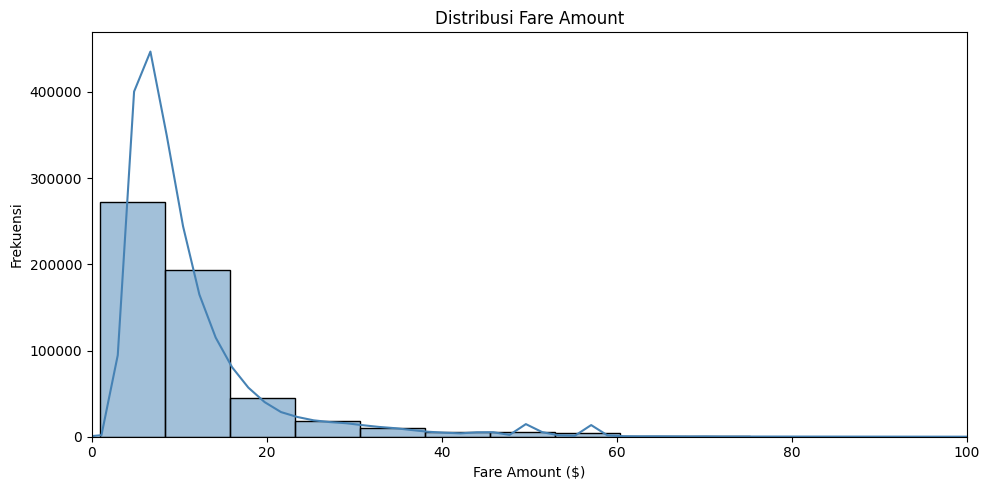

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(df_sample['fare_amount'], bins=50, kde=True, color='steelblue')
plt.title('Distribusi Fare Amount')
plt.xlabel('Fare Amount ($)')
plt.ylabel('Frekuensi')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

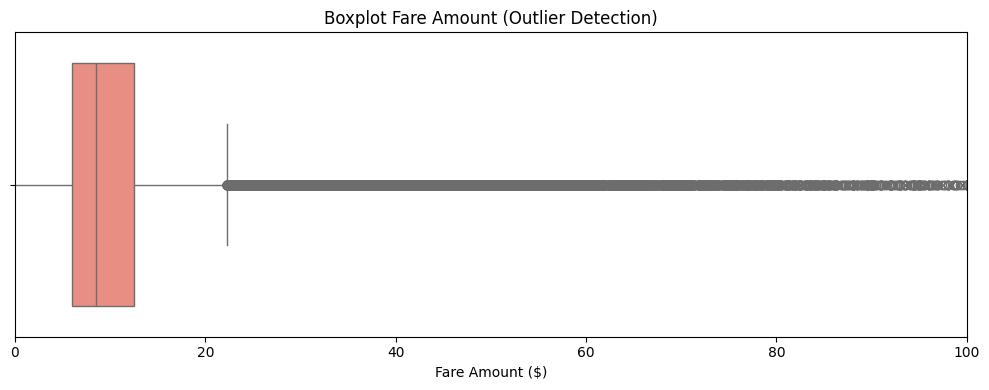

In [8]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_sample['fare_amount'], color='salmon')
plt.title('Boxplot Fare Amount (Outlier Detection)')
plt.xlabel('Fare Amount ($)')
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

C:\Users\Fathi\AppData\Local\Temp\ipykernel_25036\2617272415.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='passenger_count', data=df_sample, palette='viridis')


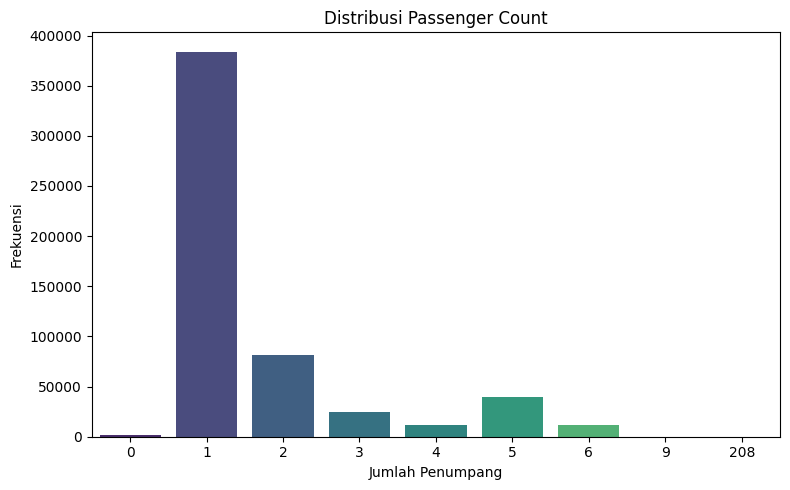

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(x='passenger_count', data=df_sample, palette='viridis')
plt.title('Distribusi Passenger Count')
plt.xlabel('Jumlah Penumpang')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

### 5. Feature Engineering & Korelasi Lanjutan (PySpark)

Pada tahap EDA, dataset awal belum memiliki indikator turunan dari jarak perjalanan seperti **indikasi kemacetan** atau **estimasi biaya tol**. Karena itu dilakukan feature engineering langsung pada DataFrame PySpark (`df`) menggunakan fungsi transformasi **`withColumn()`** agar analisis tarif (`fare_amount`) lebih informatif.

Fitur baru yang ditambahkan:
- `trip_distance_km`: estimasi jarak riil (km) dari koordinat pickup-dropoff dengan rumus Haversine.
- `pickup_hour` dan `is_peak_hour`: ekstraksi waktu pickup untuk mendeteksi jam sibuk.
- `traffic_index`: proxy sederhana tingkat kemacetan (tinggi/sedang/rendah) dari kombinasi jam sibuk dan jarak.
- `estimated_toll_usd`: estimasi biaya tol berbasis kategori jarak.

Agar hasil korelasi valid secara domain, dilakukan **data quality filtering** sebelum clipping, meliputi:
- validasi koordinat berada di area NYC (bounding box longitude-latitude),
- `fare_amount` bernilai positif dan tidak ekstrem,
- `passenger_count` pada rentang realistis,
- `trip_distance_km` pada rentang perjalanan wajar.

Setelah filtering, dilakukan pembersihan outlier lanjutan pada jarak dan fare melalui clipping kuantil (`fare_clean`, `trip_distance_km_clean`).

Setelah fitur baru terbentuk, analisis korelasi diulang untuk mengevaluasi:
1. hubungan jarak perjalanan dengan tarif taksi,
2. kontribusi faktor kemacetan,
3. keterkaitan estimasi tol terhadap nilai fare.

Jumlah baris sample untuk korelasi: 532,581
Tabel korelasi (dibulatkan 3 desimal):
                        fare_clean  trip_distance_km_clean  passenger_count  \
fare_clean                   1.000                   0.899            0.015   
trip_distance_km_clean       0.899                   1.000            0.012   
passenger_count              0.015                   0.012            1.000   
traffic_index               -0.094                  -0.111           -0.008   
estimated_toll_usd           0.806                   0.884            0.009   
pickup_hour                  0.021                  -0.017           -0.022   

                        traffic_index  estimated_toll_usd  pickup_hour  
fare_clean                     -0.094               0.806        0.021  
trip_distance_km_clean         -0.111               0.884       -0.017  
passenger_count                -0.008               0.009       -0.022  
traffic_index                   1.000              -0.094        0.271 

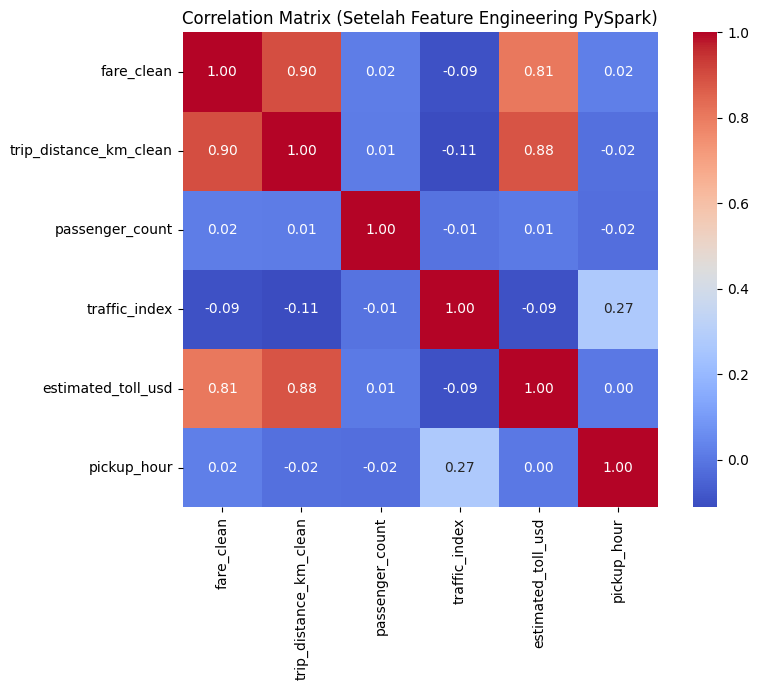

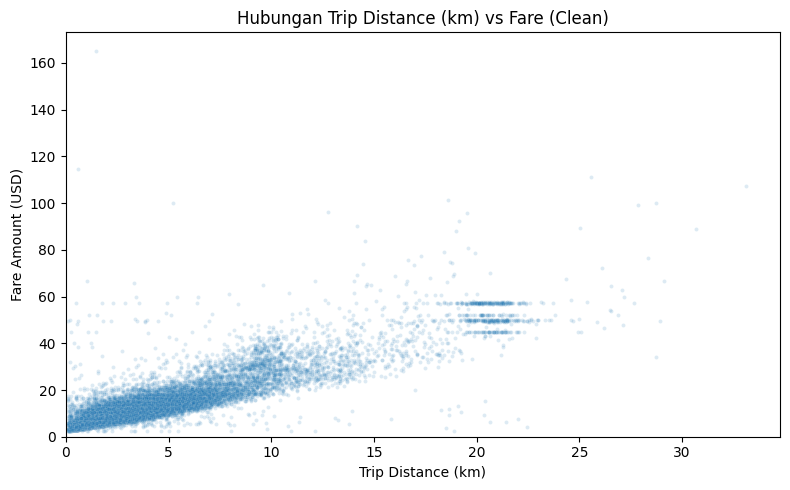

In [10]:
import pandas as pd
from pyspark.sql.functions import (
    col, when, hour, radians, sin, cos, asin, sqrt,
    lit, greatest, least
)

# --- Feature engineering langsung di PySpark (withColumn) ---
peak_hours = [7, 8, 9, 16, 17, 18, 19]

df_feat = (
    df
    .withColumn('pickup_hour', hour(col('pickup_datetime')))
    .withColumn('is_peak_hour', when(col('pickup_hour').isin(peak_hours), 1).otherwise(0))
    .withColumn(
        'trip_distance_km',
        lit(6371.0) * 2 * asin(
            sqrt(
                sin((radians(col('dropoff_latitude')) - radians(col('pickup_latitude'))) / 2) ** 2
                + cos(radians(col('pickup_latitude')))
                * cos(radians(col('dropoff_latitude')))
                * sin((radians(col('dropoff_longitude')) - radians(col('pickup_longitude'))) / 2) ** 2
            )
        )
    )
    .withColumn(
        'traffic_index',
        when((col('is_peak_hour') == 1) & (col('trip_distance_km') <= 5), 3)
        .when(col('is_peak_hour') == 1, 2)
        .otherwise(1)
    )
    .withColumn(
        'estimated_toll_usd',
        when(col('trip_distance_km') >= 12, lit(6.5))
        .when(col('trip_distance_km') >= 7, lit(3.5))
        .otherwise(lit(0.0))
    )
)

# --- Data quality filtering berbasis domain NYC ---
# Catatan: batas berikut dipilih agar anomali ekstrem (koordinat invalid / distance tidak realistis)
# tidak merusak analisis korelasi.
df_feat = (
    df_feat
    .where(col('pickup_longitude').between(-74.3, -73.6))
    .where(col('dropoff_longitude').between(-74.3, -73.6))
    .where(col('pickup_latitude').between(40.5, 41.0))
    .where(col('dropoff_latitude').between(40.5, 41.0))
    .where(col('fare_amount').between(1.0, 300.0))
    .where(col('passenger_count').between(1, 6))
    .where(col('trip_distance_km').between(0.1, 100.0))
)

# --- Transformasi agar analisis lebih konsisten (kurangi outlier sisa) ---
fare_low, fare_high = df_feat.approxQuantile('fare_amount', [0.01, 0.99], 0.01)
dist_low, dist_high = df_feat.approxQuantile('trip_distance_km', [0.01, 0.99], 0.01)

df_feat = (
    df_feat
    .withColumn(
        'fare_clean',
        least(lit(fare_high), greatest(lit(max(0.0, fare_low)), col('fare_amount')))
    )
    .withColumn(
        'trip_distance_km_clean',
        least(lit(dist_high), greatest(lit(max(0.0, dist_low)), col('trip_distance_km')))
    )
)

# --- Analisis korelasi (gunakan sample agar ringan untuk visualisasi) ---
corr_cols = [
    'fare_clean',
    'trip_distance_km_clean',
    'passenger_count',
    'traffic_index',
    'estimated_toll_usd',
    'pickup_hour'
]

df_corr_sample = (
    df_feat
    .select(*corr_cols)
    .dropna()
    .sample(fraction=0.01, seed=42)
    .toPandas()
)

print(f'Jumlah baris sample untuk korelasi: {len(df_corr_sample):,}')

corr_matrix = df_corr_sample[corr_cols].corr(numeric_only=True)

print('Tabel korelasi (dibulatkan 3 desimal):')
print(corr_matrix.round(3))

# Ringkasan korelasi terhadap fare untuk bantu interpretasi laporan
fare_corr = corr_matrix['fare_clean'].drop('fare_clean').sort_values(ascending=False)
print('\nRingkasan korelasi terhadap fare_clean:')
for feature, value in fare_corr.items():
    if abs(value) >= 0.7:
        strength = 'kuat'
    elif abs(value) >= 0.4:
        strength = 'sedang'
    elif abs(value) >= 0.2:
        strength = 'lemah'
    else:
        strength = 'sangat lemah'

    direction = 'positif' if value > 0 else 'negatif'
    print(f'- {feature}: {value:.3f} ({strength}, {direction})')

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix (Setelah Feature Engineering PySpark)')
plt.tight_layout()
plt.show()

# Visual tambahan: hubungan jarak vs fare setelah cleaning
plot_sample = df_corr_sample.sample(min(30000, len(df_corr_sample)), random_state=42)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=plot_sample,
    x='trip_distance_km_clean',
    y='fare_clean',
    alpha=0.15,
    s=8
)
plt.title('Hubungan Trip Distance (km) vs Fare (Clean)')
plt.xlabel('Trip Distance (km)')
plt.ylabel('Fare Amount (USD)')
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

C:\Users\Fathi\AppData\Local\Temp\ipykernel_25036\2919563202.py:14: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Fathi\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


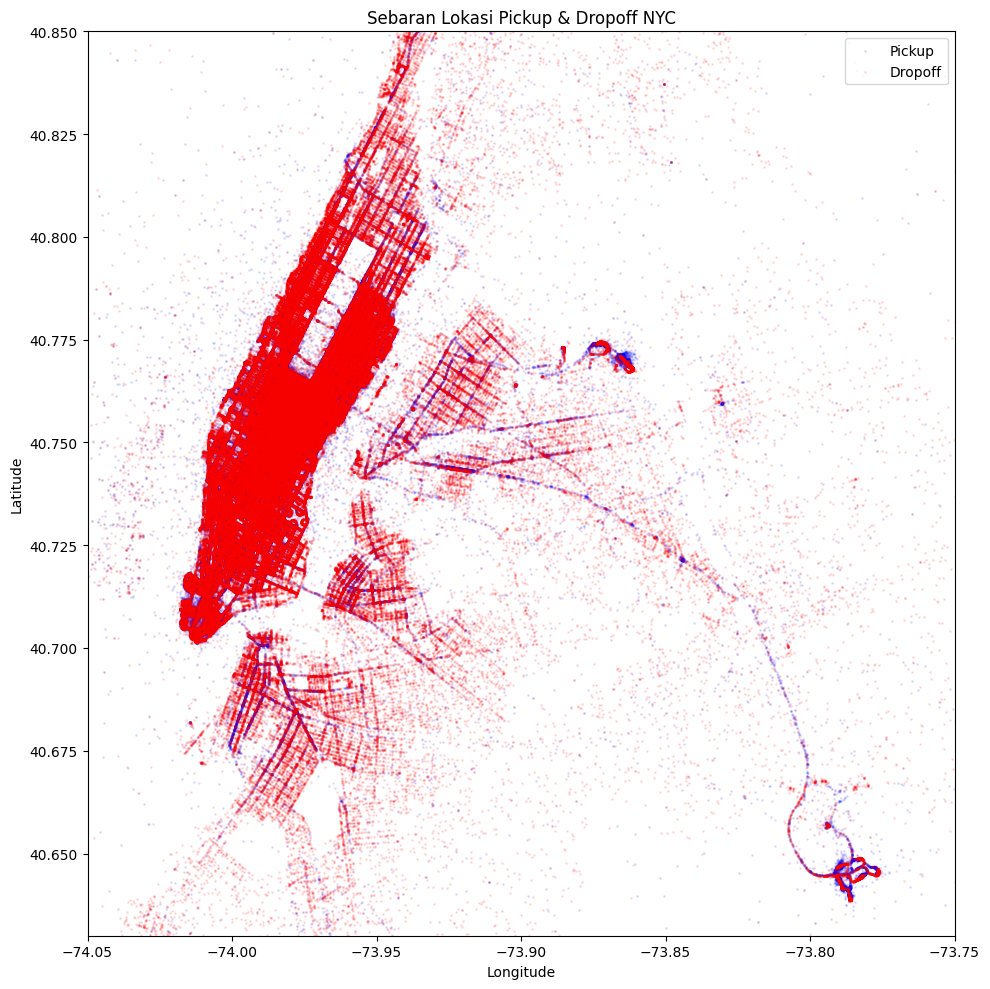

In [11]:
plt.figure(figsize=(10, 10))
plt.scatter(df_sample['pickup_longitude'], 
            df_sample['pickup_latitude'], 
            alpha=0.1, s=1, color='blue', label='Pickup')
plt.scatter(df_sample['dropoff_longitude'], 
            df_sample['dropoff_latitude'], 
            alpha=0.1, s=1, color='red', label='Dropoff')
plt.title('Sebaran Lokasi Pickup & Dropoff NYC')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(-74.05, -73.75)
plt.ylim(40.63, 40.85)
plt.legend()
plt.tight_layout()
plt.show()